# ML Project: Spam Message Classification

## Project Idea
In this project, you will build a machine learning model that classifies text messages as:

- **ham**: normal message
- **spam**: unwanted promotional or scam message

This is a **text classification / NLP project**, not an image project.

## Objectives
By the end of this notebook, you should be able to:

1. Create and load a text dataset.
2. Explore text data.
3. Clean text messages.
4. Convert text into numerical features using **TF-IDF**.
5. Split data into training and testing sets.
6. Train different machine learning models.
7. Compare model accuracy.
8. Evaluate the best model using a confusion matrix and classification report.
9. Test the model using new custom messages.

---

## 1. Import Libraries



In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Text processing
import re
import string

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

## 2. Create the Text Dataset

The dataset contains short text messages and their labels.

1. Run the cell to create the dataset.
2. Convert it into a DataFrame.
3. Display the first rows.


In [ ]:
df = pd.read_csv("/content/real_sms_spam_dataset_sample.csv")
df.head()

,label,label_num,message
0,ham,0,"Go until jurong point, crazy.. Available only ..."
1,ham,0,Ok lar... Joking wif u oni...
2,spam,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,0,U dun say so early hor... U c already then say...
4,ham,0,"Nah I don't think he goes to usf, he lives aro..."


## 3. Understand the Dataset

1. How many rows and columns are in the dataset?
2. What are the column names?
3. What are the data types?
4. How many spam and ham messages are there?
5. Are there missing values?
6. Are there duplicated messages?


In [ ]:
# Display the shape of the dataset
df.shape

(193, 3)

In [ ]:
# Display column names
df.columns

Index(['label', 'label_num', 'message'], dtype='object')

In [ ]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   label      193 non-null    object
 1   label_num  193 non-null    int64 
 2   message    193 non-null    object
dtypes: int64(1), object(2)
memory usage: 4.7+ KB


In [ ]:
# Count spam and ham messages
print(df['label'].value_counts())

label
ham     166
spam     27
Name: count, dtype: int64


In [ ]:
# Check missing values
print(df.isnull().sum())

label        0
label_num    0
message      0
dtype: int64


In [ ]:
# Check duplicated rows
print(df.duplicated().sum())

0


## 4. Text Length Analysis

Text length can sometimes help us understand patterns in spam and ham messages.

1. Create a new column called `message_length`.
2. Calculate the number of characters in each message.
3. Compare message length between spam and ham.


In [ ]:
# Create message_length column
df['message_length'] = df['message'].apply(len)

In [ ]:
# Show average message length for each label
print(df.groupby('label')['message_length'].mean())

label
ham     49.373494
spam    84.666667
Name: message_length, dtype: float64


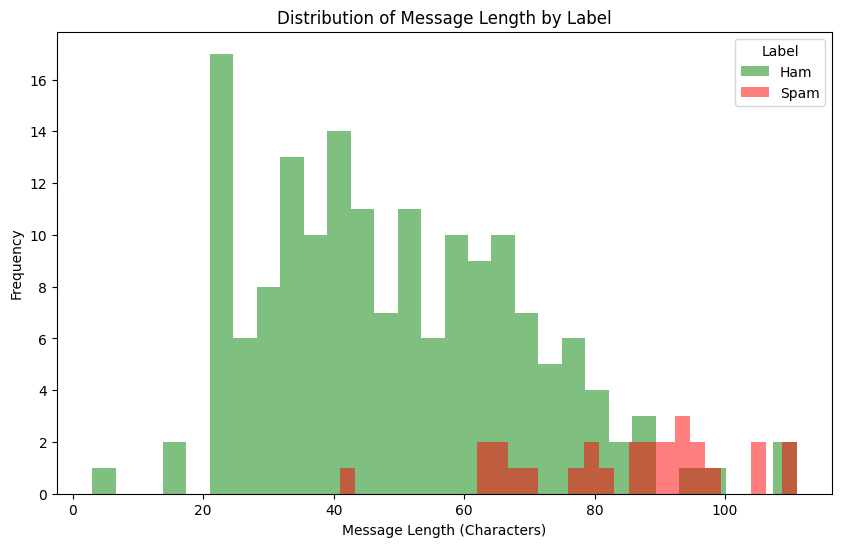

In [ ]:
# Plot message length by label

plt.figure(figsize=(10, 6))
plt.hist(df[df['label'] == 'ham']['message_length'], bins=30, alpha=0.5, label='Ham', color='green')
plt.hist(df[df['label'] == 'spam']['message_length'], bins=30, alpha=0.5, label='Spam', color='red')
plt.title('Distribution of Message Length by Label')
plt.xlabel('Message Length (Characters)')
plt.ylabel('Frequency')
plt.legend(title='Label')
plt.show()

## 5. Clean the Text

Text data usually contains uppercase letters, punctuation, numbers, and extra spaces.

We will create a function to clean text.

The function should:
1. Convert text to lowercase.
2. Remove punctuation.
3. Remove numbers.
4. Remove extra spaces.


In [ ]:
# Create clean_text function
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
# Apply the clean_text function to the message column
df['message'] = df['message'].apply(clean_text)

In [ ]:
df.head()

,label,label_num,message,message_length
0,ham,0,go until jurong point crazy available only in ...,111
1,ham,0,ok lar joking wif u oni,29
2,spam,1,free entry in a wkly comp to win fa cup final ...,111
3,ham,0,u dun say so early hor u c already then say,49
4,ham,0,nah i dont think he goes to usf he lives aroun...,61


## 6. Exploratory Data Analysis

Create visualizations to understand the dataset.

Required:
1. Bar chart showing the number of spam and ham messages.
2. Histogram of message length.
3. Show the most common words in spam messages.
4. Show the most common words in ham messages.


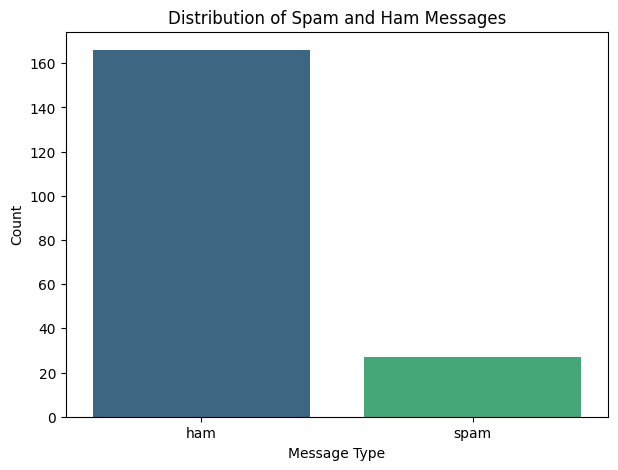

In [ ]:
# Create a bar chart for label distribution
import seaborn as sns
label_counts = df['label'].value_counts()
plt.figure(figsize=(7, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title('Distribution of Spam and Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')
plt.show()

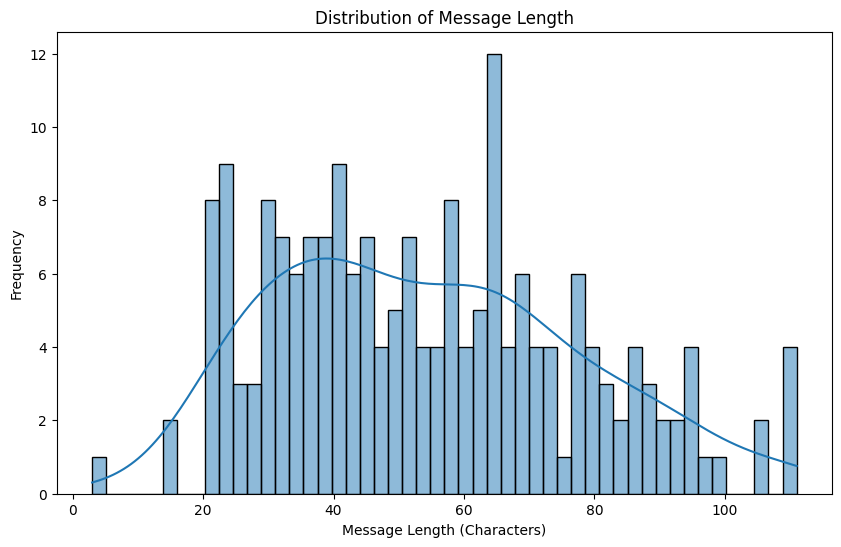

In [ ]:
# Create a histogram of message length
plt.figure(figsize=(10, 6))
sns.histplot(df['message_length'], bins=50, kde=True)
plt.title('Distribution of Message Length')
plt.xlabel('Message Length (Characters)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Helper function to get common words

from collections import Counter

def get_common_words(text_series, top_n=10):
    all_words = " ".join(text_series).split()
    word_counts = Counter(all_words)
    return pd.DataFrame(word_counts.most_common(top_n), columns=["word", "count"])

Most common words in spam messages:


,word,count
0,to,22
1,your,15
2,you,13
3,a,10
4,call,10
5,now,9
6,cash,8
7,free,7
8,text,7
9,and,7


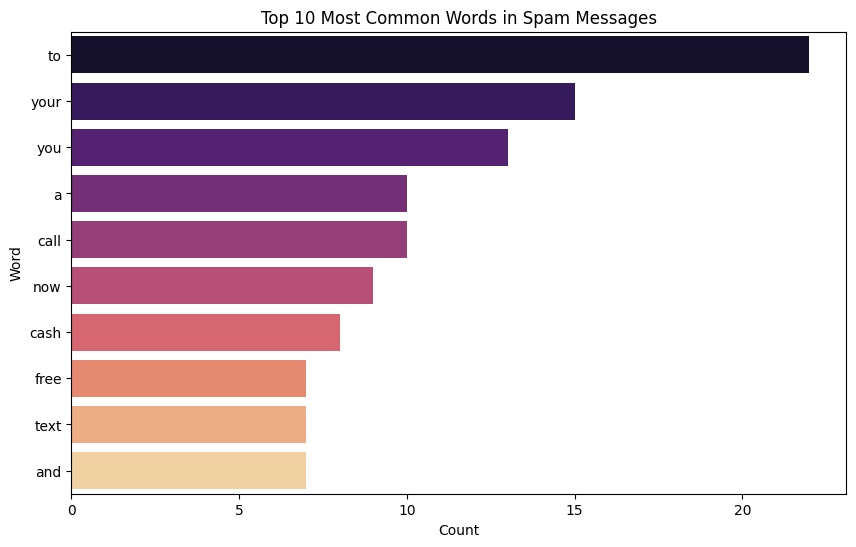

In [ ]:
# TODO: Show most common words in spam messages
spam_messages = df[df['label'] == 'spam']['message']
common_spam_words = get_common_words(spam_messages)
print("Most common words in spam messages:")
display(common_spam_words)

plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='word', data=common_spam_words, palette='magma')
plt.title('Top 10 Most Common Words in Spam Messages')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

Most common words in ham messages:


,word,count
0,i,69
1,you,54
2,to,51
3,the,26
4,and,21
5,have,21
6,it,21
7,a,20
8,in,17
9,im,17


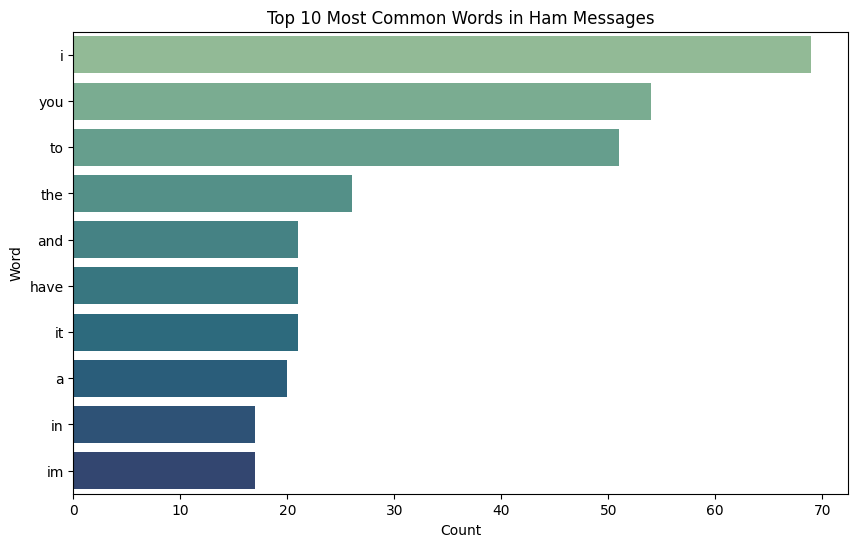

In [ ]:
# Show most common words in ham messages
ham_messages = df[df['label'] == 'ham']['message']
common_ham_words = get_common_words(ham_messages)
print("Most common words in ham messages:")
display(common_ham_words)

plt.figure(figsize=(10, 6))
sns.barplot(x='count', y='word', data=common_ham_words, palette='crest')
plt.title('Top 10 Most Common Words in Ham Messages')
plt.xlabel('Count')
plt.ylabel('Word')
plt.show()

## 7. Prepare Data for Machine Learning

Machine learning models cannot understand raw text directly.

We need to convert text into numbers using **TF-IDF Vectorization**.

1. Store cleaned messages in `X`.
2. Store labels in `y`.
3. Split the data into training and testing sets.
4. Use `test_size=0.2`.
5. Use `random_state=42`.
6. Use `stratify=y`.


In [ ]:
# Create X and y
X = df['message']
y = df['label_num']

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## 8. Convert Text to Numbers Using TF-IDF

TF-IDF means **Term Frequency - Inverse Document Frequency**.

It gives higher importance to words that are useful for classification.

1. Create a `TfidfVectorizer`.
2. Fit it on the training text only.
3. Transform the training and testing text.


In [ ]:
# TODO: Create and apply TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Shape of X_train_tfidf:", X_train_tfidf.shape)
print("Shape of X_test_tfidf:", X_test_tfidf.shape)

Shape of X_train_tfidf: (154, 651)
Shape of X_test_tfidf: (39, 651)


## 9. Train Different Machine Learning Models

we will compare several classification algorithms:

1. Multinomial Naive Bayes
2. Logistic Regression
3. Linear Support Vector Machine
4. Decision Tree
5. Random Forest

Then we will train each model and calculate accuracy.


In [ ]:
# Create a dictionary of models
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": LinearSVC(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

In [ ]:
# Train models and store accuracy scores
accuracy_scores = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores[name] = accuracy
    print(f"{name}: Accuracy = {accuracy:.4f}")

Naive Bayes: Accuracy = 0.8974
Logistic Regression: Accuracy = 0.8718
Linear SVM: Accuracy = 0.8974
Decision Tree: Accuracy = 0.9487
Random Forest: Accuracy = 0.9231


## 10. Compare Model Accuracy

1. Convert model results into a DataFrame.
2. Sort models by accuracy.
3. Create a bar chart comparing accuracy.
4. Identify the best model.


In [ ]:
# Convert results to DataFrame
accuracy_df = pd.DataFrame(accuracy_scores.items(), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False)
print("Model Accuracy Scores:")
display(accuracy_df)

Model Accuracy Scores:


,Model,Accuracy
3,Decision Tree,0.948718
4,Random Forest,0.923077
0,Naive Bayes,0.897436
2,Linear SVM,0.897436
1,Logistic Regression,0.871795


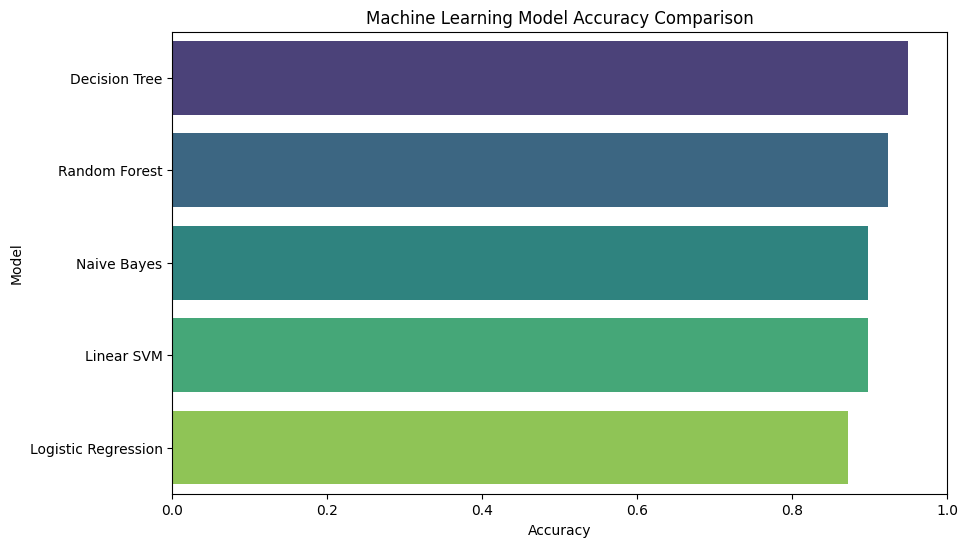


The best performing model is Decision Tree with an accuracy of 0.9487.


In [ ]:
# Plot model accuracy comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=accuracy_df, palette='viridis')
plt.title('Machine Learning Model Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.xlim(0, 1) # Accuracy is between 0 and 1
plt.show()

best_model_name = accuracy_df.iloc[0]['Model']
best_model_accuracy = accuracy_df.iloc[0]['Accuracy']
print(f"\nThe best performing model is {best_model_name} with an accuracy of {best_model_accuracy:.4f}.")

## 11. Evaluate the Best Model

After comparing all models, we will choose the best one and evaluate it more deeply.

1. Choose the best model.
2. Train it again.
3. Predict test messages.
4. Display the confusion matrix.
5. Display the classification report.


In [ ]:
# Choose the best model name based on your results
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test_tfidf)
print(f"Predictions from the best model ({best_model_name}):\n{y_pred_best}")

Predictions from the best model (Decision Tree):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


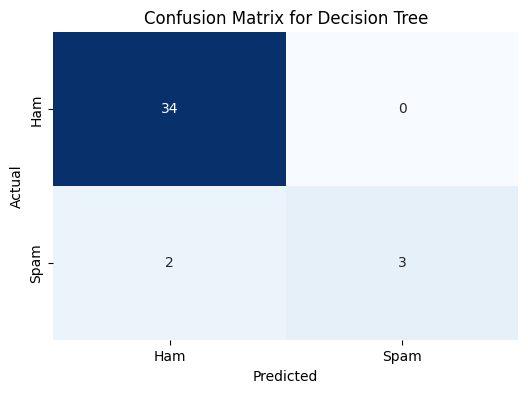

In [ ]:
# Display confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix for {best_model_name}')
plt.show()

In [ ]:
# Display classification report
report = classification_report(y_test, y_pred_best)
print(f"Classification Report for {best_model_name}:\n{report}")

Classification Report for Decision Tree:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        34
           1       1.00      0.60      0.75         5

    accuracy                           0.95        39
   macro avg       0.97      0.80      0.86        39
weighted avg       0.95      0.95      0.94        39



## 12. Test the Model With New Messages

Now try the model with new messages.

1. Write new custom messages.
2. Clean the messages.
3. Transform them using the same TF-IDF vectorizer.
4. Predict whether each message is spam or ham.


In [ ]:
# Try a messages
new_messages = [
    "WINNER! You have been selected to receive a FREE lottery prize! Text 'CLAIM' to 888 for details.",
    "Exclusive offer: Get a \$1000 gift card just for being a loyal customer! Reply YES to accept.",
    "Congratulations, you have been accepted to Tuwaiq Academy",
    "URGENT! Your bank account has been compromised. Verify your details at link",
    "You have been selected to receive a free gift card worth $1000. Text 'GIFT' to 12345 to claim.",
    "Your mobile number has won a prize of $5000. To claim, call 0800-xxxxxx now!",
    "Hey, can we meet for coffee tomorrow?",
    "Hello I am Linah, How are you?"
]

# Clean the new messages
cleaned_new_messages = [clean_text(msg) for msg in new_messages]

# Transform the new messages using the fitted TF-IDF vectorizer
new_messages_tfidf = tfidf_vectorizer.transform(cleaned_new_messages)

# Predict using the best model
new_predictions = best_model.predict(new_messages_tfidf)

# Map numerical predictions back to labels
prediction_labels = ['ham' if p == 0 else 'spam' for p in new_predictions]

# Display results
for i, message in enumerate(new_messages):
    print(f"Original: {message}")
    print(f"Cleaned: {cleaned_new_messages[i]}")
    print(f"Prediction: {prediction_labels[i]}\n")

Original: WINNER! You have been selected to receive a FREE lottery prize! Text 'CLAIM' to 888 for details.
Cleaned: winner you have been selected to receive a free lottery prize text claim to for details
Prediction: spam

Original: Exclusive offer: Get a \$1000 gift card just for being a loyal customer! Reply YES to accept.
Cleaned: exclusive offer get a gift card just for being a loyal customer reply yes to accept
Prediction: ham

Original: Congratulations, you have been accepted to Tuwaiq Academy
Cleaned: congratulations you have been accepted to tuwaiq academy
Prediction: ham

Original: URGENT! Your bank account has been compromised. Verify your details at link
Cleaned: urgent your bank account has been compromised verify your details at link
Prediction: ham

Original: You have been selected to receive a free gift card worth $1000. Text 'GIFT' to 12345 to claim.
Cleaned: you have been selected to receive a free gift card worth text gift to to claim
Prediction: spam

Original: Your m